# To plot the histogram of percentage of positive/negative labels in each run.

In [1]:
import pandas as pd
import numpy as np 
import os
import glob
from tqdm import tqdm

In [4]:

''' Define Paths Here'''
DATASET_INT_PATHS = ["/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_0_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_uav_interference/uav_scenario_2_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_1_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_a_{}_processed.csv",
            "/media/research-student/KingstonSSD1/FANET_Dataset/DJISpark_Measured_Proxy/data_manual_throughput_manet_interference/manet_scenario_2_{}_processed.csv"]
RELIABILITY_TH = 0.999 # Threshold to evaluate interference scenarios
NUM_PROCS = 32
NUM_UAV = 8
NUM_RUNS = 499 # The max run number to consider (Run_Num starts at 0)

num_samples_list = []
num_pos_list = []
num_pos_95_list = []
num_pos_90_list = []
for datasets in DATASET_INT_PATHS:
    scenario_name = datasets.split("/")[-1]
    print(scenario_name)
    print("LOADING AND PROCESSING DATA")
    ul_df = pd.read_csv(datasets.format("ul"))
    ul_df = ul_df.loc[ul_df["Run_Num"] <= NUM_RUNS]
    ul_df.sort_values(by=["UAV_Speed", "UAV_Height", "Bit_Rate", "USI", "Time"], inplace=True)
    len_df = len(ul_df)
    dl_df_list = []
    for i in range(NUM_UAV):
        df = pd.read_csv(datasets.format("UAV_" + str(i)))
        df = df.loc[df["Run_Num"] <= NUM_RUNS]
        df.sort_values(by=["UAV_Speed", "UAV_Height", "Bit_Rate", "USI", "Time"], inplace=True)
        assert len(df) == len_df, "UAV-{} DF Not Same Length".format(i)
        dl_df_list.append(df)

    # Combine data to one DF
    ul_df.rename(columns={"Measured_Reliability_1": "UL_Measured_Reliability_1"}, inplace=True)
    for i in range(NUM_UAV):
        ul_df["UAV_{}_Measured_Reliability_1".format(i)] = dl_df_list[i]["Measured_Reliability_1"]

    # Remove NaNs, but combine them first
    ul_df.dropna(subset=["UL_Measured_Reliability_1", "UAV_0_Measured_Reliability_1", "UAV_1_Measured_Reliability_1", 
                        "UAV_2_Measured_Reliability_1", "UAV_3_Measured_Reliability_1", "UAV_4_Measured_Reliability_1",
                        "UAV_5_Measured_Reliability_1", "UAV_6_Measured_Reliability_1", "UAV_7_Measured_Reliability_1"], inplace=True)

    # Filter samples with "Time" < 1
    ul_df = ul_df.loc[ul_df["Time"] >= 1]

    # Ground truths 
    ul_df["Failure_Occur"] = (ul_df["UAV_0_Measured_Reliability_1"] < RELIABILITY_TH) | (ul_df["UAV_7_Measured_Reliability_1"] < RELIABILITY_TH) | \
                                                (ul_df["UAV_1_Measured_Reliability_1"] < RELIABILITY_TH) | (ul_df["UAV_2_Measured_Reliability_1"] < RELIABILITY_TH) | \
                                                (ul_df["UAV_3_Measured_Reliability_1"] < RELIABILITY_TH) | (ul_df["UAV_4_Measured_Reliability_1"] < RELIABILITY_TH) | \
                                                (ul_df["UAV_5_Measured_Reliability_1"] < RELIABILITY_TH) | (ul_df["UAV_6_Measured_Reliability_1"] < RELIABILITY_TH) | \
                                                (ul_df["UL_Measured_Reliability_1"] < RELIABILITY_TH)

    # Label whether any reliability is below 90% or 95%
    ul_df["Fail_Below_90"] = (ul_df["UAV_0_Measured_Reliability_1"] < 0.9) | (ul_df["UAV_7_Measured_Reliability_1"] < 0.9) | \
                                                (ul_df["UAV_1_Measured_Reliability_1"] < 0.9) | (ul_df["UAV_2_Measured_Reliability_1"] < 0.9) | \
                                                (ul_df["UAV_3_Measured_Reliability_1"] < 0.9) | (ul_df["UAV_4_Measured_Reliability_1"] < 0.9) | \
                                                (ul_df["UAV_5_Measured_Reliability_1"] < 0.9) | (ul_df["UAV_6_Measured_Reliability_1"] < 0.9) | \
                                                (ul_df["UL_Measured_Reliability_1"] < 0.9)
    ul_df["Fail_Below_95"] = (ul_df["UAV_0_Measured_Reliability_1"] < 0.95) | (ul_df["UAV_7_Measured_Reliability_1"] < 0.95) | \
                                                (ul_df["UAV_1_Measured_Reliability_1"] < 0.95) | (ul_df["UAV_2_Measured_Reliability_1"] < 0.95) | \
                                                (ul_df["UAV_3_Measured_Reliability_1"] < 0.95) | (ul_df["UAV_4_Measured_Reliability_1"] < 0.95) | \
                                                (ul_df["UAV_5_Measured_Reliability_1"] < 0.95) | (ul_df["UAV_6_Measured_Reliability_1"] < 0.95) | \
                                                (ul_df["UL_Measured_Reliability_1"] < 0.95)

    # Get sensitivity, specificity, and modified FNR for each run of each combination, and find averages over all runs for each combination
    df_groups = ul_df.groupby(['USI', 'Bit_Rate', 'UAV_Height', 'UAV_Speed'])
    group_mean_results_list = []
    print("EVALUATING EACH GROUP")
    for group in tqdm(set(df_groups.groups.keys())):
        group_df = df_groups.get_group(group)
        run_groups = group_df.groupby(["Run_Num"])
        for run_group in set(run_groups.groups.keys()):
            run_df = run_groups.get_group(run_group)
            num_samples = len(run_df)
            num_pos = run_df["Failure_Occur"].sum()
            num_pos_90 = run_df["Fail_Below_90"].sum()
            num_pos_95 = run_df["Fail_Below_95"].sum()
            num_samples_list.append(num_samples)
            num_pos_list.append(num_pos)
            num_pos_90_list.append(num_pos_90)
            num_pos_95_list.append(num_pos_95)


uav_scenario_0_{}_processed.csv
LOADING AND PROCESSING DATA


EVALUATING EACH GROUP


100%|██████████| 275/275 [00:45<00:00,  5.98it/s]


uav_scenario_1_{}_processed.csv
LOADING AND PROCESSING DATA
EVALUATING EACH GROUP


100%|██████████| 275/275 [00:44<00:00,  6.13it/s]


...

100%|██████████| 275/275 [00:45<00:00,  6.09it/s]


manet_scenario_a_{}_processed.csv
LOADING AND PROCESSING DATA
EVALUATING EACH GROUP


100%|██████████| 275/275 [00:45<00:00,  6.10it/s]


manet_scenario_2_{}_processed.csv
LOADING AND PROCESSING DATA
EVALUATING EACH GROUP


100%|██████████| 275/275 [00:45<00:00,  6.11it/s]


In [5]:
# Save as arrays
num_samples_arr = np.array(num_samples_list)
num_pos_arr = np.array(num_pos_90_list)
num_pos_90_arr = np.array(num_pos_90_list)
num_pos_95_arr = np.array(num_pos_95_list)

num_neg_arr = num_samples_arr - num_pos_arr
num_neg_90_arr = num_samples_arr - num_pos_90_arr
num_neg_95_arr = num_samples_arr - num_pos_95_arr

np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Samples_All_Runs.npy", num_samples_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_999_All_Runs.npy", num_pos_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_999_All_Runs.npy", num_neg_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_95_All_Runs.npy", num_pos_95_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_95_All_Runs.npy", num_neg_95_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_90_All_Runs.npy", num_pos_90_arr)
np.save("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_90_All_Runs.npy", num_neg_90_arr)

Text(0, 0.5, 'Density')

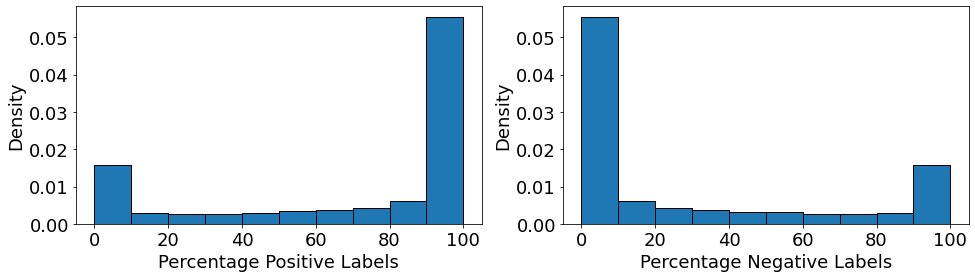

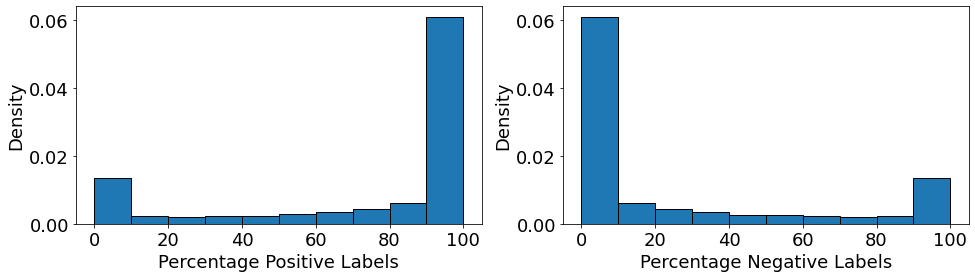

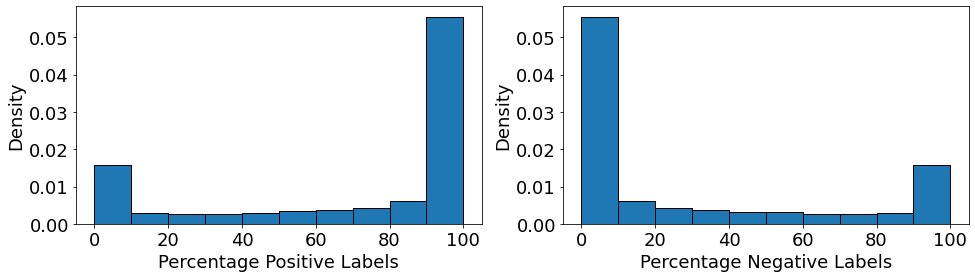

In [10]:
# Plot the histograms
import matplotlib.pyplot as plt

# num_samples_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Samples_All_Runs.npy")
# num_pos_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_999_All_Runs.npy")
# num_pos_95_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_95_All_Runs.npy")
# num_pos_90_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Positive_90_All_Runs.npy")
# num_neg_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_999_All_Runs.npy")
# num_neg_95_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_95_All_Runs.npy")
# num_neg_90_arr = np.load("/home/research-student/reuben_ws/omnet-fanet/results_new_Mar25/Num_Negative_90_All_Runs.npy")

# For Positive and Negative Samples (reliability threshold 99.9%)
percent_pos = num_pos_arr / num_samples_arr * 100
percent_neg = num_neg_arr / num_samples_arr * 100

plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
ax1.hist(percent_pos, density=True, edgecolor='k')
ax1.set_xlabel("Percentage Positive Labels")
ax1.set_ylabel("Density")

ax2.hist(percent_neg, density=True, edgecolor='k')
ax2.set_xlabel("Percentage Negative Labels")
ax2.set_ylabel("Density")

# For Positive and Negative Samples (reliability threshold 95%)
percent_95_pos = num_pos_95_arr / num_samples_arr * 100
percent_95_neg = num_neg_95_arr / num_samples_arr * 100

plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
ax1.hist(percent_95_pos, density=True, edgecolor='k')
ax1.set_xlabel("Percentage Positive Labels")
ax1.set_ylabel("Density")

ax2.hist(percent_95_neg, density=True, edgecolor='k')
ax2.set_xlabel("Percentage Negative Labels")
ax2.set_ylabel("Density")

# For Positive and Negative Samples (reliability threshold 90%)
percent_90_pos = num_pos_90_arr / num_samples_arr * 100
percent_90_neg = num_neg_90_arr / num_samples_arr * 100

plt.rcParams.update({'font.size': 18, 'xtick.labelsize':'medium', 'font.family': 'sans-serif'})
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
ax1.hist(percent_90_pos, density=True, edgecolor='k')
ax1.set_xlabel("Percentage Positive Labels")
ax1.set_ylabel("Density")

ax2.hist(percent_90_neg, density=True, edgecolor='k')
ax2.set_xlabel("Percentage Negative Labels")
ax2.set_ylabel("Density")